In [1]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
tfd = tfp.distributions
tfb = tfp.bijectors
vi = tfp.vi

import matplotlib.pyplot as plt
from bakeoff.TensorFlow_Prob.run_tfp import make_conditioned_lp
from tqdm import tqdm

In [2]:
mu_prior, sigma_prior = 0, 10
sigma_like = 1.0
max_iters = 100_000
target_log_prob_fn = make_conditioned_lp(
  prior_dist = tfd.Normal(mu_prior, sigma_prior),
  likelihood_dist = lambda z: tfd.Normal(z, sigma_like),
  x = np.array([])
)


In [3]:
def run_restart(seed):
    q_loc = tf.Variable(0.0, name=f'q_loc', dtype=np.float32)
    q_scale = tf.Variable(10.0, name=f'q_scale', dtype=np.float32)
    surrogate_posterior = tfd.Normal(loc=q_loc, scale=q_scale)

    q_loc_2 = tf.Variable(0.0, name=f'q_loc_2', dtype=np.float32)
    q_scale_2 = tf.Variable(10.0, name=f'q_scale_2', dtype=np.float32)
    surrogate_posterior_2 = tfd.Normal(loc=q_loc_2, scale=q_scale_2)


    q_z_single = tfp.experimental.util.make_trainable(tfd.Normal, name='q_z')
    q_z_multiple = tfp.experimental.util.make_trainable(tfd.Normal, name='q_z')

    def trace_fn_single(traceable_quantities):
        return q_z_single.mean(), q_z_single.stddev(), traceable_quantities.loss

    def trace_fn_multiple(traceable_quantities):
        return q_z_multiple.mean(), q_z_multiple.stddev(), traceable_quantities.loss

    single_sample_losses = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn,
        seed=seed,
        surrogate_posterior=q_z_single,
        trainable_variables=q_z_single.trainable_variables,
        optimizer=tf.optimizers.Adam(),#learning_rate=0.01, epsilon=1e-8),
        trace_fn= trace_fn_single,
        num_steps=max_iters
        )
    multi_sample_losses = tfp.vi.fit_surrogate_posterior(
        target_log_prob_fn,
        seed=seed+1000,
        surrogate_posterior=q_z_multiple,
        trainable_variables=q_z_multiple.trainable_variables,
        optimizer=tf.optimizers.Adam(),
        trace_fn= trace_fn_multiple,
        num_steps=max_iters,
        sample_size=100)
    return single_sample_losses, multi_sample_losses

In [8]:
# results = [
#     run_restart(seed) for seed in tqdm(range(100))
# ]

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import os

# Jupyter-safe multithreading replacement for:
# results = [run_restart(seed) for seed in tqdm(range(100))]

seeds = list(range(100))

results = [run_restart(seed) for seed in tqdm(seeds)]
# run_restart(0) # 43 sec for 10k, so should be around 75 min for 20 runs of 50k
# max_workers = min(8, (os.cpu_count() or 8))  # adjust if you want (e.g., 4/8/16)

# with ThreadPoolExecutor(max_workers=max_workers) as ex:
#     futures = {ex.submit(run_restart, seed): seed for seed in seeds}
#     for fut in tqdm(as_completed(futures), total=len(futures)):
#         seed = futures[fut]
#         results[seed] = fut.result()

100%|██████████| 100/100 [12:07:24<00:00, 436.44s/it]  


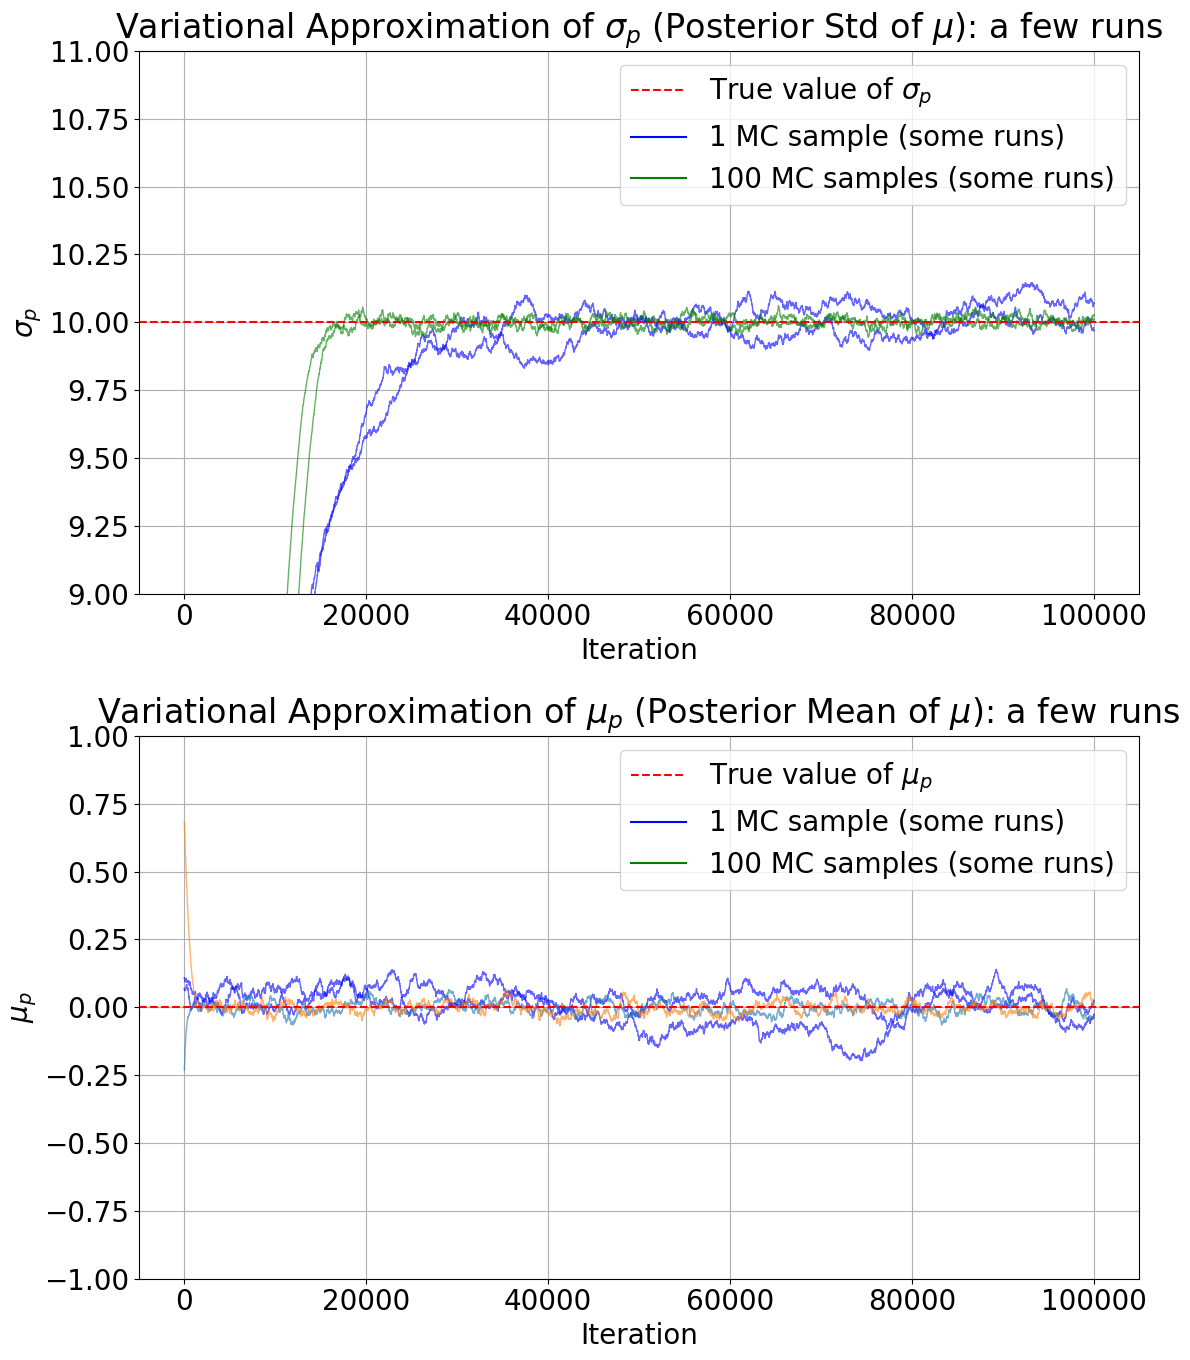

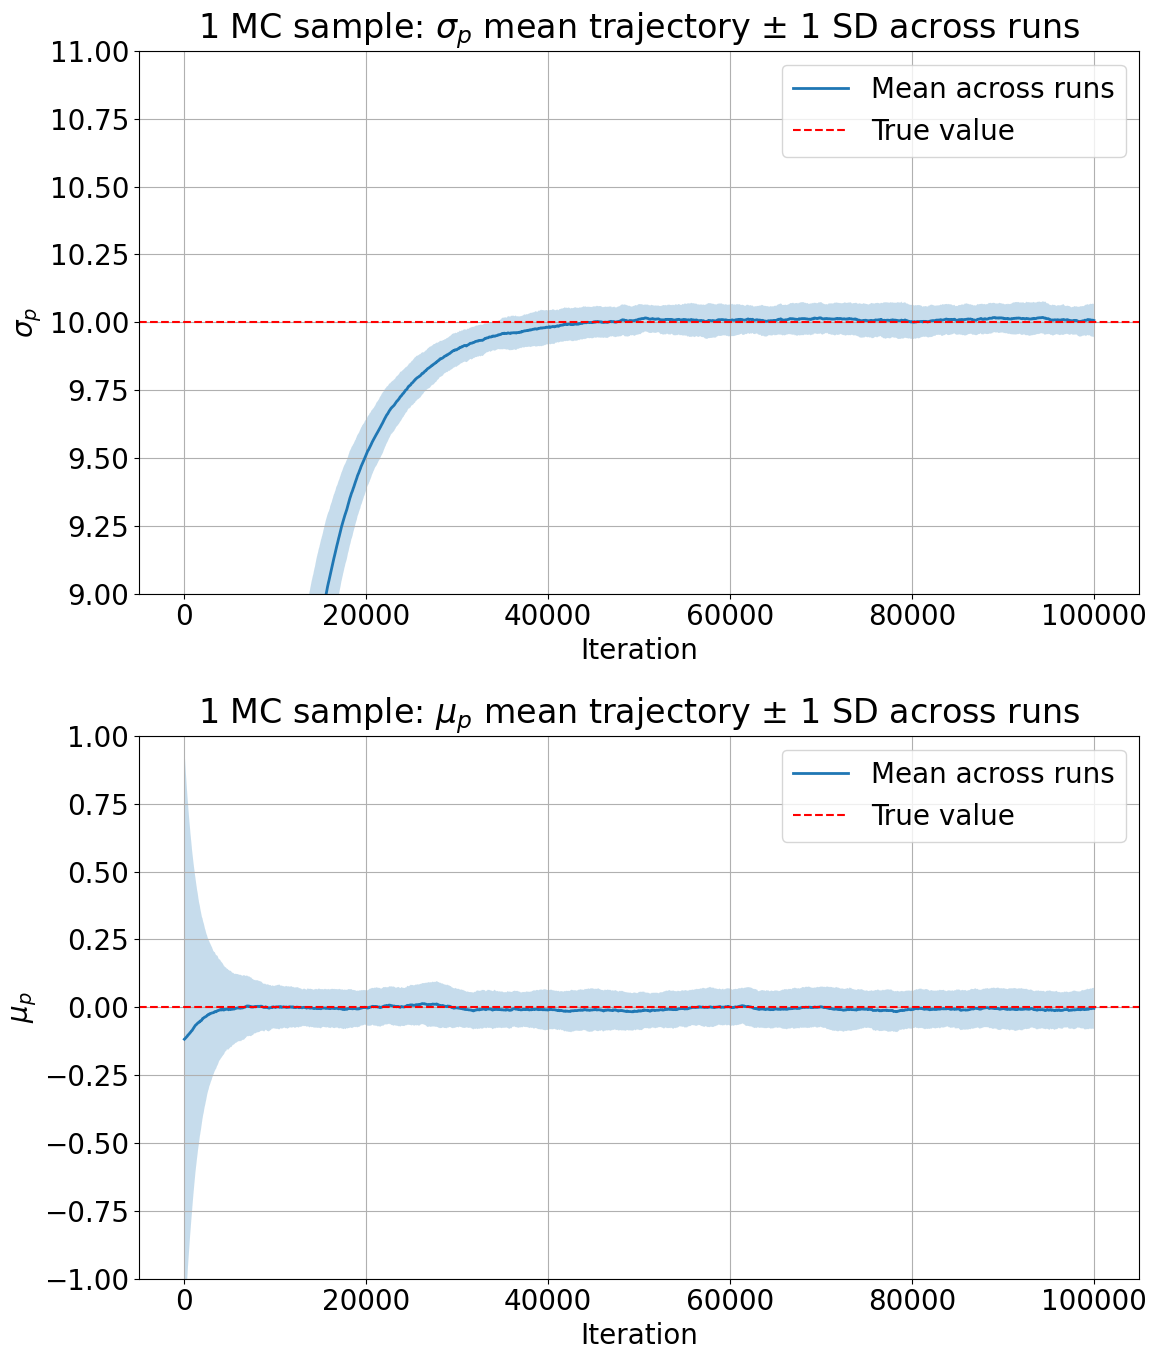

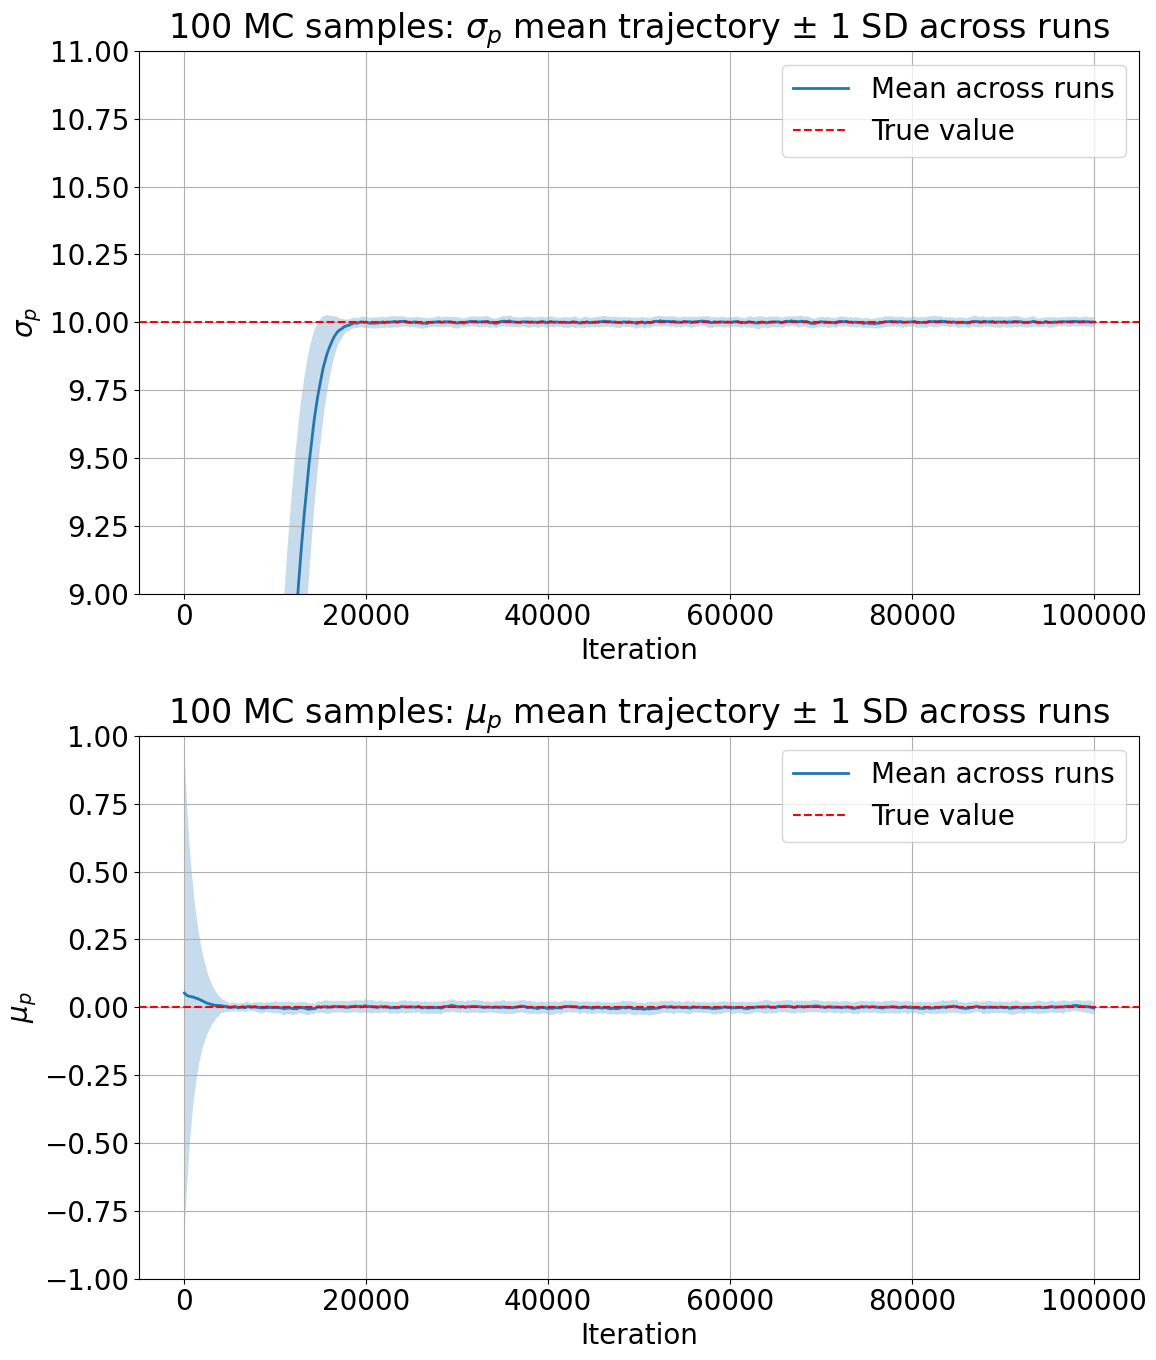

In [10]:
plt.rcParams.update({'font.size': 20})

# ----------------------------
# unpack results -> stacks
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_tracker, multi_tracker in results:
    single_means.append(single_tracker[0])
    single_stds.append(single_tracker[1])
    multi_means.append(multi_tracker[0])
    multi_stds.append(multi_tracker[1])

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
x = np.arange(T)

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(sigma_prior, color='red', linestyle='--', label=r'True value of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(mu_prior, color='red', linestyle='--', label=r'True value of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='True value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, sigma_prior,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, single_means, mu_prior,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, sigma_prior,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(sigma_prior - 1, sigma_prior + 1)

plot_mean_band(
    axs[1], x, multi_means, mu_prior,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(mu_prior - 1, mu_prior + 1)

plt.tight_layout()
plt.show()